<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_RNA/blob/main/RNA_trabalho03_forecasting_daily_temperatures_S%C3%A9rgio_Costa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 3: Forecasting

Aluno: Sérgio Henrique Cerqueira Costa - 20251MPCA0080

Disciplina: Redes Neurais Artificiais

Professor: Francisco Boldt

Este notebook aplica técnicas de **forecasting** vistas em aula a uma base diferente da usada pelo professor.

Base escolhida: **Daily Minimum Temperatures** — série temporal univariada com temperaturas mínimas diárias de Melbourne, Austrália, entre 1981 e 1990.

Objetivo: prever a temperatura mínima do **próximo dia** a partir dos **30 dias anteriores**.

## 1. Importações

Uso de `tensorflow.keras`, `numpy`, `pandas` e `matplotlib`, mantendo a estrutura próxima ao exemplo da aula.

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(42)

## 2. Carregamento da base

A base contém temperaturas mínimas diárias registradas em Melbourne, Austrália. Ela é diferente da base **Jena Climate**, usada no exemplo de sala de aula.

Como a série possui uma única variável (`Temp`), o problema é tratado como forecasting **univariado**. Por estar no hemisfério sul, a sazonalidade anual aparece com comportamento compatível com as estações locais.

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

fname = keras.utils.get_file(
    fname="daily-min-temperatures.csv",
    origin=url
)

df = pd.read_csv(fname)
df["Date"] = pd.to_datetime(df["Date"])

df.head()

67921/67921 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [ ]:
print(df.info())
print("\nQuantidade de registros:", len(df))
print("Data inicial:", df["Date"].min())
print("Data final:", df["Date"].max())
print("Valores ausentes por coluna:")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3650 non-null   datetime64[ns]
 1   Temp    3650 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 57.2 KB
None

Quantidade de registros: 3650
Data inicial: 1981-01-01 00:00:00
Data final: 1990-12-31 00:00:00
Valores ausentes por coluna:
Date    0
Temp    0
dtype: int64


## 3. Transformação em array

A coluna `Temp` é transformada em um array NumPy. Para usar `timeseries_dataset_from_array`, o array de entrada precisa ficar no formato:

`(quantidade_de_observações, quantidade_de_variáveis)`

Neste caso, a quantidade de variáveis é 1.

In [ ]:
temperature = df["Temp"].astype("float32").values
raw_data = temperature.reshape(-1, 1)

print("temperature shape:", temperature.shape)
print("raw_data shape:", raw_data.shape)

temperature shape: (3650,)
raw_data shape: (3650, 1)


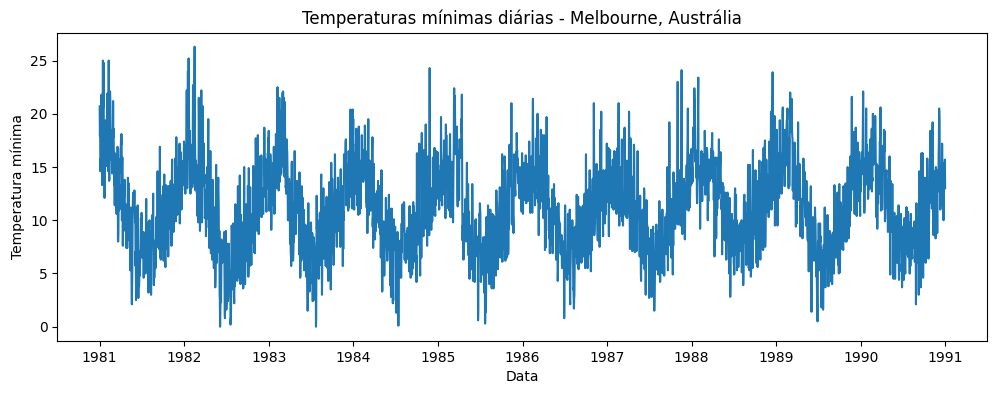

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(df["Date"], temperature)
plt.title("Temperaturas mínimas diárias - Melbourne, Austrália")
plt.xlabel("Data")
plt.ylabel("Temperatura mínima")
plt.show()

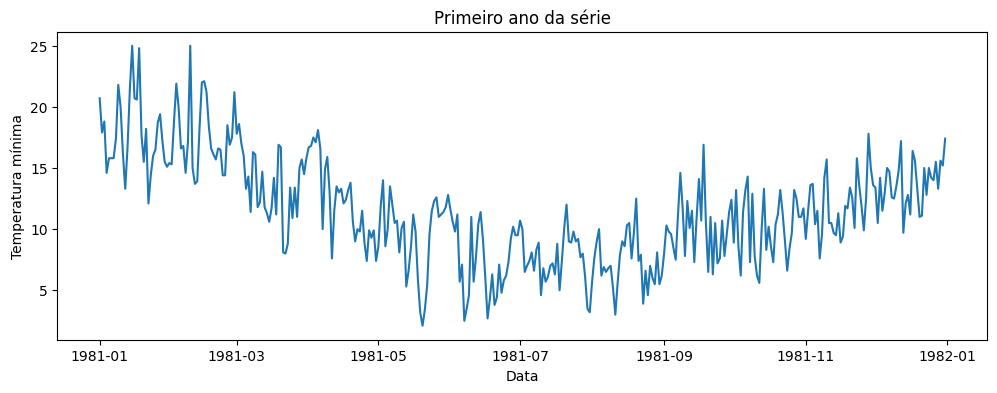

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(df["Date"][:365], temperature[:365])
plt.title("Primeiro ano da série")
plt.xlabel("Data")
plt.ylabel("Temperatura mínima")
plt.show()

## 4. Separação entre treino, validação e teste

Foi mantida uma divisão simples e temporal:

- 50% para treino;
- 25% para validação;
- 25% para teste.

A ordem temporal foi preservada. Isso é importante em séries temporais, pois não devemos treinar o modelo com dados futuros para prever o passado.

In [ ]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples

print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 1825
num_val_samples: 912
num_test_samples: 913


## 5. Normalização

A normalização é feita usando apenas a média e o desvio padrão do conjunto de treino.

Isso evita vazamento de informação, pois validação e teste representam dados futuros. Os alvos serão mantidos na escala original da temperatura, para que o MAE possa ser interpretado diretamente na unidade da base.

In [ ]:
mean = raw_data[:num_train_samples].mean(axis=0)
std = raw_data[:num_train_samples].std(axis=0)

raw_data = (raw_data - mean) / std

print("Média do treino:", mean[0])
print("Desvio padrão do treino:", std[0])

Média do treino: 11.043507
Desvio padrão do treino: 4.261552


## 6. Geração dos datasets de série temporal

Parâmetros usados:

- `sequence_length = 30`: usa os 30 dias anteriores como entrada;
- `sampling_rate = 1`: usa todos os dias, sem pular observações;
- `horizon = 1`: prevê 1 dia à frente;
- `delay = sequence_length + horizon - 1`: desloca o alvo para o dia seguinte ao fim da janela;
- `batch_size = 32`: valor simples e suficiente para uma base pequena.

Embora a base tenha sazonalidade anual, foi usada uma janela curta de 30 dias porque o objetivo é prever apenas o dia seguinte. Para esse horizonte, o comportamento recente da série tende a ser uma referência forte. Uma janela de aproximadamente 365 dias aumentaria a complexidade do problema e reduziria a quantidade de exemplos disponíveis para treinamento.

In [ ]:
sampling_rate = 1
sequence_length = 30
horizon = 1
delay = sampling_rate * (sequence_length + horizon - 1)
batch_size = 32

train_dataset = keras.utils.timeseries_dataset_from_array(
    data=raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    data=raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=False,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    data=raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=False,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples
)

In [ ]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

print("Batches de treino por época:", train_dataset.cardinality().numpy())
print("Batches de validação por época:", val_dataset.cardinality().numpy())
print("Batches de teste:", test_dataset.cardinality().numpy())

samples shape: (32, 30, 1)
targets shape: (32,)
Batches de treino por época: 57
Batches de validação por época: 28
Batches de teste: 27


## 7. Baseline Naïve

A técnica ingênua usada como baseline prevê que a temperatura mínima de amanhã será igual à temperatura mínima de hoje.

Como os dados de entrada foram normalizados, a última observação da janela é convertida de volta para a escala original antes do cálculo do MAE.

In [ ]:
def get_naive_predictions(dataset):
    all_preds = []
    all_targets = []

    for samples, targets in dataset:
        preds = samples[:, -1, 0].numpy() * std[0] + mean[0]
        all_preds.append(preds)
        all_targets.append(targets.numpy())

    return np.concatenate(all_targets), np.concatenate(all_preds)


def evaluate_naive_method(dataset):
    targets, preds = get_naive_predictions(dataset)
    return np.mean(np.abs(preds - targets))

naive_val_mae = evaluate_naive_method(val_dataset)
naive_test_mae = evaluate_naive_method(test_dataset)

print(f"Naïve - Validation MAE: {naive_val_mae:.2f}")
print(f"Naïve - Test MAE: {naive_test_mae:.2f}")

Naïve - Validation MAE: 2.06
Naïve - Test MAE: 2.08


## 8. Funções auxiliares para treinamento

Os modelos serão treinados com limite máximo de 50 épocas e `EarlyStopping`. Assim, evita-se parar cedo demais quando o modelo ainda está aprendendo, mas também se evita continuar o treinamento sem ganho na validação.

In [ ]:
def make_callbacks(filename):
    return [
        keras.callbacks.ModelCheckpoint(
            filename,
            monitor="val_mae",
            mode="min",
            save_best_only=True
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_mae",
            mode="min",
            patience=5,
            restore_best_weights=True
        )
    ]


def compile_and_fit(model, checkpoint_filename, epochs=50):
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    history = model.fit(
        train_dataset,
        epochs=epochs,
        validation_data=val_dataset,
        callbacks=make_callbacks(checkpoint_filename)
    )
    best_model = keras.models.load_model(checkpoint_filename)
    test_mae = best_model.evaluate(test_dataset)[1]
    return best_model, history, test_mae


def plot_history(history, title):
    loss = history.history["mae"]
    val_loss = history.history["val_mae"]
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, loss, label="Training MAE")
    plt.plot(epochs, val_loss, label="Validation MAE")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("MAE")
    plt.legend()
    plt.show()

## 9. Modelo densamente conectado

Este modelo achata a janela temporal de 30 dias e usa uma camada densa simples. Ele serve como uma primeira rede neural, mas não preserva explicitamente a estrutura sequencial dos dados.

In [ ]:
keras.backend.clear_session()
keras.utils.set_random_seed(42)

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model_dense, history_dense, dense_test_mae = compile_and_fit(
    model,
    "daily_temp_dense.keras",
    epochs=50
)

print(f"Dense - Test MAE: {dense_test_mae:.2f}")

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 115.0320 - mae: 9.8644 - val_loss: 102.0324 - val_mae: 9.3838
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 78.8154 - mae: 7.9447 - val_loss: 67.9724 - val_mae: 7.4188
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 49.1713 - mae: 5.9431 - val_loss: 43.5069 - val_mae: 5.6349
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 36.0908 - mae: 4.9245 - val_loss: 33.3043 - val_mae: 4.7428
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 33.1485 - mae: 4.6948 - val_loss: 30.3434 - val_mae: 4.4888
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 31.4146 - mae: 4.5653 - val_loss: 29.2051 - val_mae: 4.4166
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 29.6120 - mae: 4.4329 - val_loss: 26.9889 - val_mae: 4.2315
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 27.8943 - mae: 4.3015 - val_loss: 25.6043 - val_mae: 4.1226
Epoch 9/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

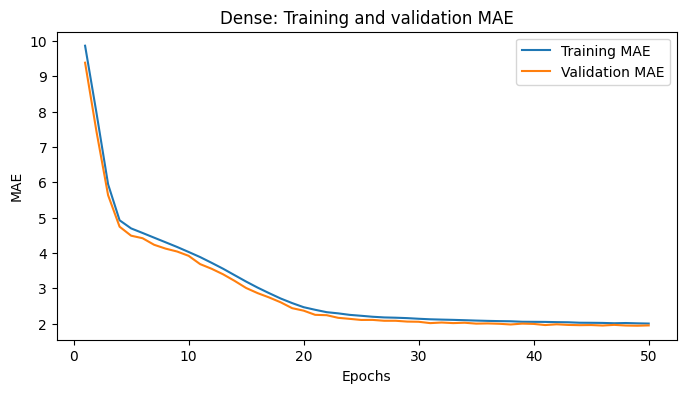

In [ ]:
plot_history(history_dense, "Dense: Training and validation MAE")

## 10. Modelo Conv1D

A rede convolucional 1D aplica filtros sobre a sequência temporal. Ela é uma alternativa simples entre o modelo densamente conectado e os modelos recorrentes. Vale notar que o `GlobalAveragePooling1D` faz uma média ao longo do tempo e, com isso, dilui a informação de recência — justamente o que torna a persistência forte nesta série —, o que ajuda a explicar por que este foi o modelo mais fraco.

In [ ]:
keras.backend.clear_session()
keras.utils.set_random_seed(42)

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 3, activation="relu")(inputs)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model_conv1d, history_conv1d, conv1d_test_mae = compile_and_fit(
    model,
    "daily_temp_conv1d.keras",
    epochs=50
)

print(f"Conv1D - Test MAE: {conv1d_test_mae:.2f}")

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 126.0913 - mae: 10.3676 - val_loss: 125.0236 - val_mae: 10.4914
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 117.7399 - mae: 9.9646 - val_loss: 116.7832 - val_mae: 10.0911
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 108.7786 - mae: 9.5219 - val_loss: 107.7707 - val_mae: 9.6443
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 99.0117 - mae: 9.0210 - val_loss: 97.8973 - val_mae: 9.1287
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 88.3652 - mae: 8.4506 - val_loss: 87.2276 - val_mae: 8.5459
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 77.2429 - mae: 7.8210 - val_loss: 76.1668 - val_mae: 7.9039
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 66.0116 - mae: 7.1414 - val_loss: 64.9008 - val_mae: 7.2040
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 55.1739 - mae: 6.4313 - val_loss: 54.1438 - val_mae: 6.4861
Epoch 9/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18m

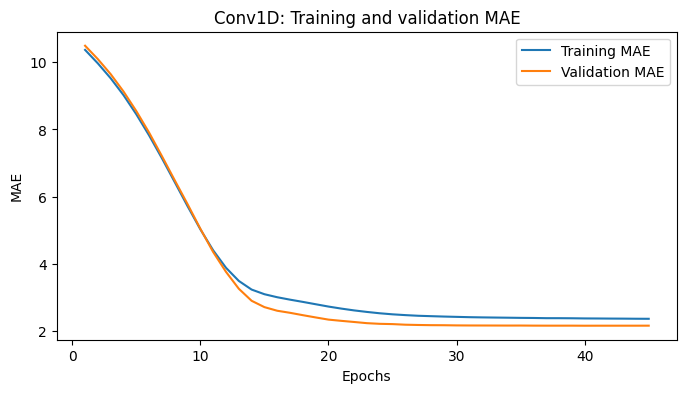

In [ ]:
plot_history(history_conv1d, "Conv1D: Training and validation MAE")

## 11. Modelo LSTM

A LSTM é uma rede recorrente adequada para sequências, pois mantém uma memória interna durante a leitura da janela temporal.

In [ ]:
keras.backend.clear_session()
keras.utils.set_random_seed(42)

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model_lstm, history_lstm, lstm_test_mae = compile_and_fit(
    model,
    "daily_temp_lstm.keras",
    epochs=50
)

print(f"LSTM - Test MAE: {lstm_test_mae:.2f}")

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 114.4437 - mae: 9.9016 - val_loss: 80.8382 - val_mae: 8.2113
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 67.5912 - mae: 7.1785 - val_loss: 55.7131 - val_mae: 6.5617
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 48.0749 - mae: 5.8284 - val_loss: 39.7069 - val_mae: 5.3416
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 35.4444 - mae: 4.8452 - val_loss: 29.0501 - val_mae: 4.4346
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 27.1811 - mae: 4.1559 - val_loss: 21.6803 - val_mae: 3.7473
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 21.3200 - mae: 3.6416 - val_loss: 16.5744 - val_mae: 3.2169
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 16.9650 - mae: 3.2219 - val_loss: 12.8143 - val_mae: 2.7733
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 13.8607 - mae: 2.8888 - val_loss: 10.3876 - val_mae: 2.4753
Epoch 9/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/s

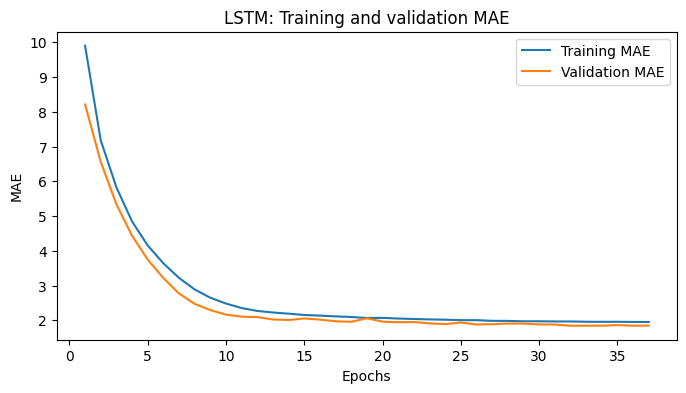

In [ ]:
plot_history(history_lstm, "LSTM: Training and validation MAE")

## 12. Comparação final

A tabela abaixo compara o baseline Naïve com os modelos neurais treinados.

Quanto menor o MAE, melhor o resultado.

Como os resultados vêm de uma única semente e as margens entre os modelos próximos são pequenas, a ordem exata entre eles pode variar entre execuções.

In [ ]:
results = pd.DataFrame([
    {"Modelo": "Naïve", "Validation MAE": naive_val_mae, "Test MAE": naive_test_mae},
    {"Modelo": "Dense", "Validation MAE": min(history_dense.history["val_mae"]), "Test MAE": dense_test_mae},
    {"Modelo": "Conv1D", "Validation MAE": min(history_conv1d.history["val_mae"]), "Test MAE": conv1d_test_mae},
    {"Modelo": "LSTM", "Validation MAE": min(history_lstm.history["val_mae"]), "Test MAE": lstm_test_mae},
])

results = results.sort_values("Test MAE").reset_index(drop=True)
results

,Modelo,Validation MAE,Test MAE
0,LSTM,1.845964,1.857868
1,Dense,1.940681,1.965539
2,Naïve,2.060023,2.083841
3,Conv1D,2.158233,2.183987


## 13. Previsões em um trecho do teste

O gráfico abaixo compara os valores reais com as previsões em um trecho do conjunto de teste. Isso ajuda a visualizar por que o baseline Naïve é uma referência importante em previsão de curto prazo.

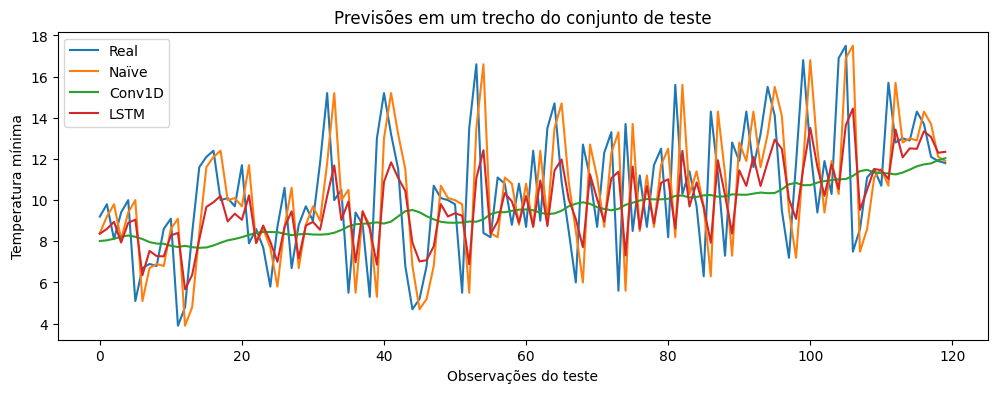

In [ ]:
def get_model_predictions(model, dataset):
    y_true = []
    y_pred = []

    for samples, targets in dataset:
        preds = model.predict(samples, verbose=0).squeeze()
        y_pred.append(np.atleast_1d(preds))
        y_true.append(targets.numpy())

    return np.concatenate(y_true), np.concatenate(y_pred)


y_true, y_naive = get_naive_predictions(test_dataset)
_, y_conv1d = get_model_predictions(model_conv1d, test_dataset)
_, y_lstm = get_model_predictions(model_lstm, test_dataset)

n = 120
plt.figure(figsize=(12, 4))
plt.plot(y_true[:n], label="Real")
plt.plot(y_naive[:n], label="Naïve")
plt.plot(y_conv1d[:n], label="Conv1D")
plt.plot(y_lstm[:n], label="LSTM")
plt.title("Previsões em um trecho do conjunto de teste")
plt.xlabel("Observações do teste")
plt.ylabel("Temperatura mínima")
plt.legend()
plt.show()

## 14. Conclusão

Neste trabalho, foi usada a base Daily Minimum Temperatures, com 3.650 registros de temperaturas mínimas diárias de Melbourne, Austrália, entre 1981 e 1990. A série foi organizada como um problema de forecasting supervisionado, usando os 30 dias anteriores para prever o dia seguinte.

Os parâmetros mantêm o experimento simples e compatível com a periodicidade diária da base: `sequence_length = 30` (cerca de um mês de histórico), `sampling_rate = 1` (sem pular observações), `horizon = 1` (previsão de curto prazo) e `batch_size = 32` (adequado ao tamanho reduzido da base). A separação treino/validação/teste respeitou a ordem temporal, e a normalização usou apenas estatísticas do treino.

O treinamento foi feito com até 50 épocas e EarlyStopping, restaurando os melhores pesos de validação. Os MAEs de teste foram: LSTM = 1.86, Dense = 1.97, Naïve = 2.08 e Conv1D = 2.18. A LSTM obteve o melhor desempenho, superando o baseline Naïve.

O resultado reforça a importância de comparar redes neurais com um baseline simples: em previsão de curto prazo, repetir o último valor observado é uma referência forte, mas modelos treinados adequadamente conseguiram superá-la.